In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

# Load data

In [2]:
fields = pd.read_csv("outputs/2.0-discovery_results.csv")
canonical = pd.read_csv(
    "outputs/4.2-final_labeled_field_profiles.csv",
    usecols=["metadata_field", "canonical_name", "confidence"],
)

In [3]:
data = fields.merge(canonical, on="metadata_field", how="left")
data

,snapshot_id,snapshot_type,source,model,metadata_field,observed_value,description,source_level,discovery_value,reasoning,canonical_name,confidence
0,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,figure_title,Figure 2: Share of food expenditure in total e...,The title or caption identifying the figure an...,snapshot,high,The figure title provides the most direct sear...,title,high
1,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,indicator_name,Share of food expenditure in total expenditure...,The main measure or indicator represented in t...,snapshot,high,Indicator-level metadata enables retrieval of ...,indicator_name,high
2,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,subject_domain,Food expenditure; food security,The thematic domain or topical area represente...,both,high,The figure title and document metadata both co...,subject_domain,high
3,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,geographic_scope,"Jordan, inferred from parent document title an...","The country, region, or geographic area to whi...",document,high,Geographic context is essential for discovery ...,geographic_scope,high
4,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,time_period,Not identifiable from this snapshot,"The date, year, or period covered by the data ...",snapshot,high,A data time period would be highly useful for ...,time_period,high
...,...,...,...,...,...,...,...,...,...,...,...,...
3036,document_10395051_table_002.png,table,prwp,gpt-5.5,significance_notation,"*, ** and *** denote significance at the 10 pe...",Notation used to indicate statistical signific...,snapshot,medium,Significance notation is needed to interpret c...,interpretive_note,high
3037,document_10395051_table_002.png,table,prwp,gpt-5.5,robustness_adjustment,Heteroskedasticity-robust t(z)-statistics are ...,Adjustments or corrections applied to reported...,snapshot,medium,Inference adjustments improve reuse by indicat...,analysis_method,medium
3038,document_10395051_table_002.png,table,prwp,gpt-5.5,endogenous_variable,Each of four informality measures,Variables treated as endogenous in instrumenta...,snapshot,medium,Endogeneity treatment is important for underst...,indicator_name,medium
3039,document_10395051_table_002.png,table,prwp,gpt-5.5,instrumental_variables,Law and order; Business regulatory freedom; Av...,Instruments used in instrumental-variable regr...,snapshot,high,Instrumental variables are key metadata for di...,not_in_ontology,high


# Build incidence matrix

In [4]:
# Drop not_in_ontology
data = data[data["canonical_name"] != "not_in_ontology"].copy()
data

,snapshot_id,snapshot_type,source,model,metadata_field,observed_value,description,source_level,discovery_value,reasoning,canonical_name,confidence
0,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,figure_title,Figure 2: Share of food expenditure in total e...,The title or caption identifying the figure an...,snapshot,high,The figure title provides the most direct sear...,title,high
1,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,indicator_name,Share of food expenditure in total expenditure...,The main measure or indicator represented in t...,snapshot,high,Indicator-level metadata enables retrieval of ...,indicator_name,high
2,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,subject_domain,Food expenditure; food security,The thematic domain or topical area represente...,both,high,The figure title and document metadata both co...,subject_domain,high
3,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,geographic_scope,"Jordan, inferred from parent document title an...","The country, region, or geographic area to whi...",document,high,Geographic context is essential for discovery ...,geographic_scope,high
4,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,time_period,Not identifiable from this snapshot,"The date, year, or period covered by the data ...",snapshot,high,A data time period would be highly useful for ...,time_period,high
...,...,...,...,...,...,...,...,...,...,...,...,...
3034,document_10395051_table_002.png,table,prwp,gpt-5.5,statistical_measures_reported,Regression coefficients; heteroskedasticity-ro...,Types of statistical quantities reported in th...,snapshot,high,This field supports discovery of tables contai...,measure_type,high
3036,document_10395051_table_002.png,table,prwp,gpt-5.5,significance_notation,"*, ** and *** denote significance at the 10 pe...",Notation used to indicate statistical signific...,snapshot,medium,Significance notation is needed to interpret c...,interpretive_note,high
3037,document_10395051_table_002.png,table,prwp,gpt-5.5,robustness_adjustment,Heteroskedasticity-robust t(z)-statistics are ...,Adjustments or corrections applied to reported...,snapshot,medium,Inference adjustments improve reuse by indicat...,analysis_method,medium
3038,document_10395051_table_002.png,table,prwp,gpt-5.5,endogenous_variable,Each of four informality measures,Variables treated as endogenous in instrumenta...,snapshot,medium,Endogeneity treatment is important for underst...,indicator_name,medium


In [5]:
df = pd.crosstab(data["snapshot_id"], data["canonical_name"]).clip(upper=1)
df

canonical_name,analysis_method,calculation_method,category_dimension,category_labels,column_dimension,comparison_group,currency,data_collection_method,data_source,financial_metric,...,series_labels,source_document_title,source_organization,subject_domain,subject_summary,temporal_granularity,time_period,title,unit_of_measure,visualization_type
snapshot_id,,,,,,,,,,,,,,,,,,,,,
002_BOSIB-ca473522-8ad0-4c80-9f0d-88bf887f2a2f_table_001.png,0,0,0,1,1,0,0,0,0,1,...,0,0,1,0,1,0,0,0,1,0
004_BOSIB-87c444de-4797-4bf9-b654-4932a7fb0112_figure_000.png,0,0,0,1,0,0,0,0,1,0,...,0,1,0,0,0,0,0,1,1,1
004_BOSIB-87c444de-4797-4bf9-b654-4932a7fb0112_table_002.png,0,0,0,1,1,0,1,0,0,0,...,0,0,0,0,0,0,1,1,1,0
004_BOSIB-87c444de-4797-4bf9-b654-4932a7fb0112_table_006.png,0,0,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,1,1,1,0
004_BOSIB-87c444de-4797-4bf9-b654-4932a7fb0112_table_008.png,0,0,0,1,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
unhcr_global_report_2020_-_west_and_central_africa_table_001.png,0,1,0,0,1,0,1,0,0,1,...,0,0,0,1,0,0,1,1,0,0
white_paper_social_media_3_0_figure_003.png,0,0,1,0,0,0,0,0,1,0,...,1,0,0,1,1,1,1,1,1,1
wincap_2020-2021_pdm_report_-final_table_004.png,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,1,1,1,1,0


# Pairwise co-occurence heatmap

`P(B | A) = cooccur(A,B) / support(A)`

In [6]:
cooccur = df.T.dot(df)
cooccur

canonical_name,analysis_method,calculation_method,category_dimension,category_labels,column_dimension,comparison_group,currency,data_collection_method,data_source,financial_metric,...,series_labels,source_document_title,source_organization,subject_domain,subject_summary,temporal_granularity,time_period,title,unit_of_measure,visualization_type
canonical_name,,,,,,,,,,,,,,,,,,,,,
analysis_method,41,5,18,13,18,5,2,0,15,0,...,5,10,0,18,13,7,28,41,24,16
calculation_method,5,26,5,9,18,3,3,1,13,2,...,4,4,2,17,4,3,19,26,22,6
category_dimension,18,5,91,49,24,10,5,4,53,2,...,21,17,10,56,13,13,73,87,81,58
category_labels,13,9,49,109,41,7,11,6,62,8,...,11,16,19,60,15,13,81,104,103,63
column_dimension,18,18,24,41,93,14,20,4,35,12,...,12,13,15,53,23,9,68,85,82,14
comparison_group,5,3,10,7,14,26,0,0,11,0,...,9,9,2,19,2,1,20,25,24,13
currency,2,3,5,11,20,0,26,0,7,11,...,3,1,3,20,4,3,19,26,23,6
data_collection_method,0,1,4,6,4,0,0,9,2,0,...,1,0,4,5,2,2,8,6,9,4
data_source,15,13,53,62,35,11,7,2,98,1,...,19,18,11,55,14,16,83,95,93,66


In [7]:
support = data.groupby("canonical_name").agg(snapshot_count=("snapshot_id", "nunique")).to_dict()["snapshot_count"]
support

{'analysis_method': 41,
 'calculation_method': 26,
 'category_dimension': 91,
 'category_labels': 109,
 'column_dimension': 93,
 'comparison_group': 26,
 'currency': 26,
 'data_collection_method': 9,
 'data_source': 98,
 'financial_metric': 15,
 'financing_instrument': 7,
 'financing_source': 10,
 'geographic_entities': 42,
 'geographic_granularity': 27,
 'geographic_role': 12,
 'geographic_scope': 194,
 'indicator_definition': 11,
 'indicator_name': 194,
 'internal_identifier': 27,
 'interpretive_note': 49,
 'intervention_type': 18,
 'language': 26,
 'location_type': 17,
 'measure_type': 46,
 'panel_title': 5,
 'population_group': 99,
 'project_component': 8,
 'project_identifier': 28,
 'project_name': 38,
 'reference_date': 32,
 'row_dimension': 105,
 'series_dimension': 13,
 'series_labels': 38,
 'source_document_title': 33,
 'source_organization': 33,
 'subject_domain': 121,
 'subject_summary': 41,
 'temporal_granularity': 28,
 'time_period': 156,
 'title': 195,
 'unit_of_measure':

In [8]:
cooccur_norm = cooccur.copy()
for c in cooccur.columns:
    cooccur_norm[c] = cooccur_norm[c] / support[c]

cooccur_norm

canonical_name,analysis_method,calculation_method,category_dimension,category_labels,column_dimension,comparison_group,currency,data_collection_method,data_source,financial_metric,...,series_labels,source_document_title,source_organization,subject_domain,subject_summary,temporal_granularity,time_period,title,unit_of_measure,visualization_type
canonical_name,,,,,,,,,,,,,,,,,,,,,
analysis_method,1.000000,0.192308,0.197802,0.119266,0.193548,0.192308,0.076923,0.000000,0.153061,0.000000,...,0.131579,0.303030,0.000000,0.148760,0.317073,0.250000,0.179487,0.210256,0.129730,0.155340
calculation_method,0.121951,1.000000,0.054945,0.082569,0.193548,0.115385,0.115385,0.111111,0.132653,0.133333,...,0.105263,0.121212,0.060606,0.140496,0.097561,0.107143,0.121795,0.133333,0.118919,0.058252
category_dimension,0.439024,0.192308,1.000000,0.449541,0.258065,0.384615,0.192308,0.444444,0.540816,0.133333,...,0.552632,0.515152,0.303030,0.462810,0.317073,0.464286,0.467949,0.446154,0.437838,0.563107
category_labels,0.317073,0.346154,0.538462,1.000000,0.440860,0.269231,0.423077,0.666667,0.632653,0.533333,...,0.289474,0.484848,0.575758,0.495868,0.365854,0.464286,0.519231,0.533333,0.556757,0.611650
column_dimension,0.439024,0.692308,0.263736,0.376147,1.000000,0.538462,0.769231,0.444444,0.357143,0.800000,...,0.315789,0.393939,0.454545,0.438017,0.560976,0.321429,0.435897,0.435897,0.443243,0.135922
comparison_group,0.121951,0.115385,0.109890,0.064220,0.150538,1.000000,0.000000,0.000000,0.112245,0.000000,...,0.236842,0.272727,0.060606,0.157025,0.048780,0.035714,0.128205,0.128205,0.129730,0.126214
currency,0.048780,0.115385,0.054945,0.100917,0.215054,0.000000,1.000000,0.000000,0.071429,0.733333,...,0.078947,0.030303,0.090909,0.165289,0.097561,0.107143,0.121795,0.133333,0.124324,0.058252
data_collection_method,0.000000,0.038462,0.043956,0.055046,0.043011,0.000000,0.000000,1.000000,0.020408,0.000000,...,0.026316,0.000000,0.121212,0.041322,0.048780,0.071429,0.051282,0.030769,0.048649,0.038835
data_source,0.365854,0.500000,0.582418,0.568807,0.376344,0.423077,0.269231,0.222222,1.000000,0.066667,...,0.500000,0.545455,0.333333,0.454545,0.341463,0.571429,0.532051,0.487179,0.502703,0.640777


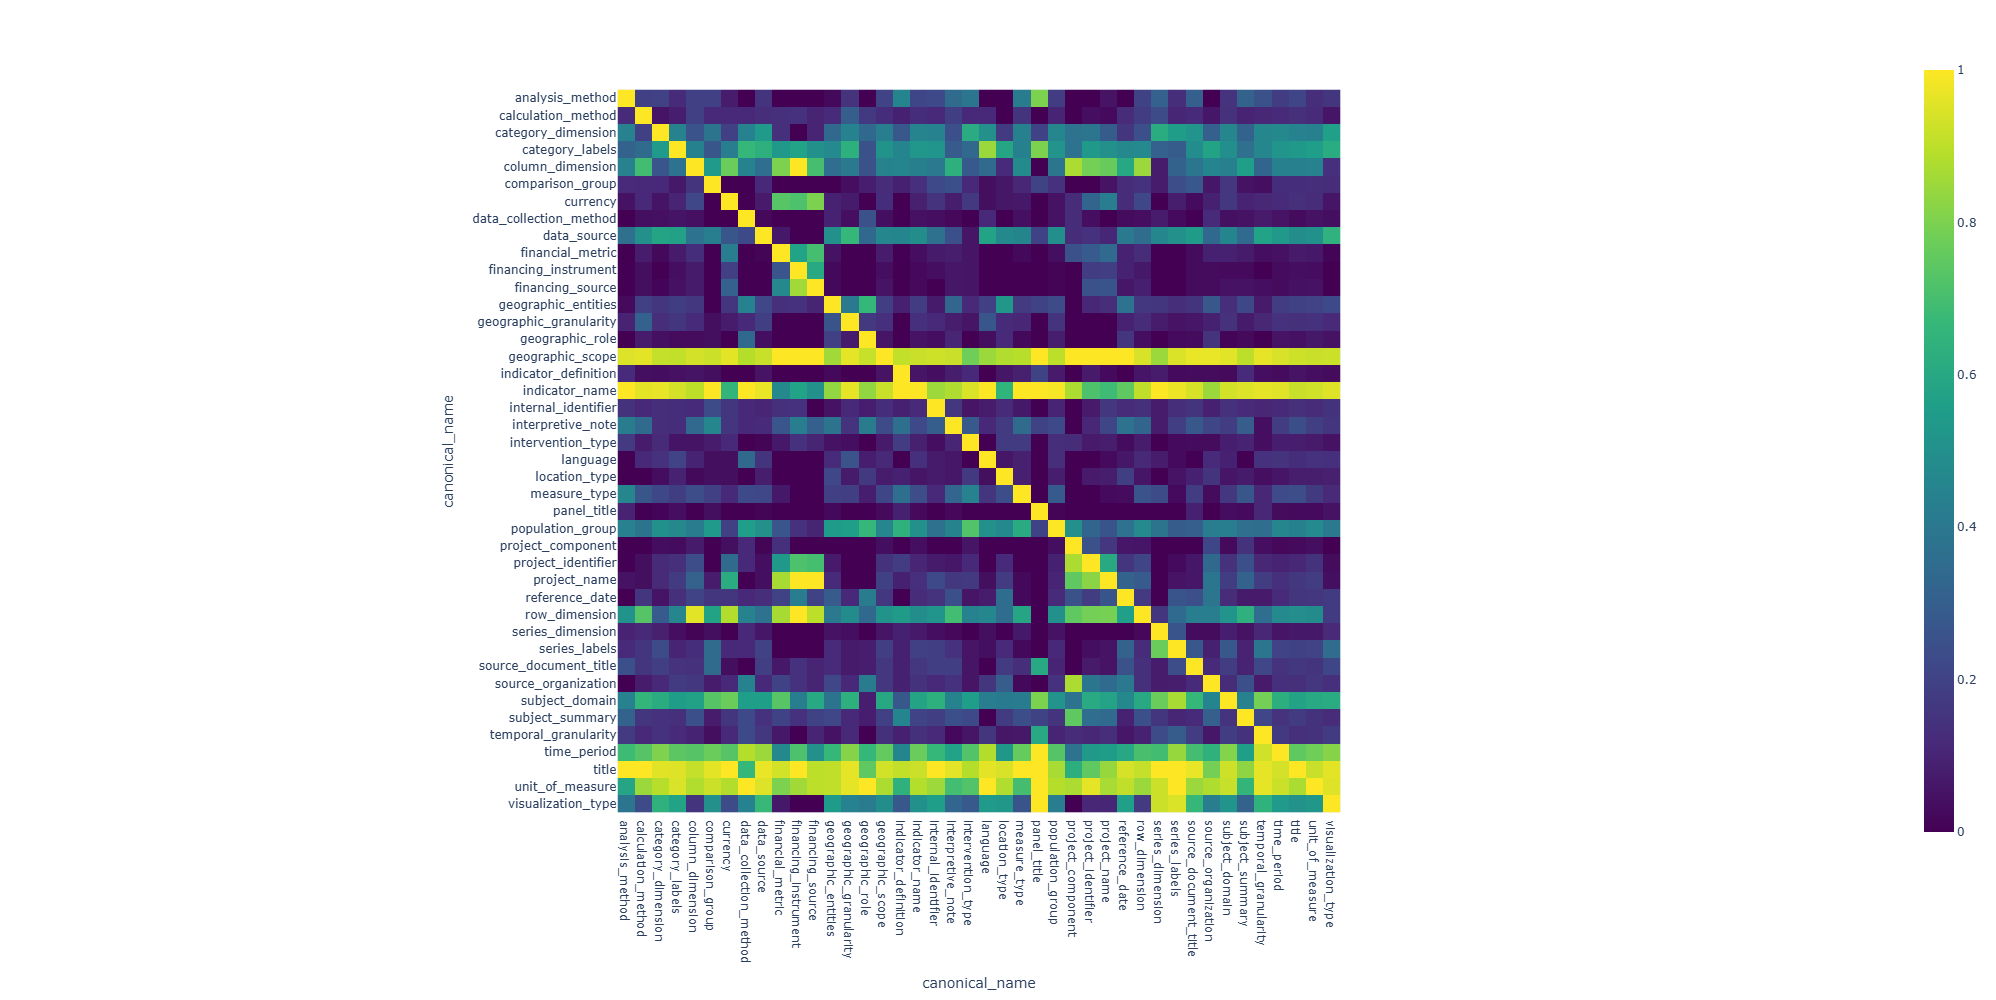

In [9]:
fig = px.imshow(
    cooccur_norm,
    height=1000,
    width=1000,
    color_continuous_scale='Viridis'
)
fig.show()

# Co-occurrence tabular

In [10]:
cooccur_df = (
    cooccur.rename_axis(index="A", columns="B").stack().reset_index(name="n_snapshots")
)

# Remove diagonals
cooccur_df = cooccur_df[cooccur_df["A"] != cooccur_df["B"]].copy()

cooccur_df

,A,B,n_snapshots
1,analysis_method,calculation_method,5
2,analysis_method,category_dimension,18
3,analysis_method,category_labels,13
4,analysis_method,column_dimension,18
5,analysis_method,comparison_group,5
...,...,...,...
1758,visualization_type,subject_summary,13
1759,visualization_type,temporal_granularity,18
1760,visualization_type,time_period,84
1761,visualization_type,title,99


In [11]:
# P(B | A) = cooccur(A,B) / support(A)
cooccur_df["conditional_support"] = cooccur_df.apply(lambda row: row["n_snapshots"] / support[row["A"]], axis=1)

cooccur_df = cooccur_df.sort_values(["conditional_support", "n_snapshots"], ascending=False)

cooccur_df.head(30)

,A,B,n_snapshots,conditional_support
983,measure_type,indicator_name,46,1.0
1005,measure_type,title,46,1.0
17,analysis_method,indicator_name,41,1.0
39,analysis_method,title,41,1.0
1191,project_name,geographic_scope,38,1.0
1383,series_labels,title,38,1.0
1384,series_labels,unit_of_measure,38,1.0
1233,reference_date,geographic_scope,32,1.0
1149,project_identifier,geographic_scope,28,1.0
795,internal_identifier,title,27,1.0


# Snapshot type

In [12]:
def create_tabular_cooccur(data):
    df = pd.crosstab(data["snapshot_id"], data["canonical_name"]).clip(upper=1)
    cooccur = df.T.dot(df)
    cooccur_df = (
        cooccur.rename_axis(index="A", columns="B")
        .stack()
        .reset_index(name="n_snapshots")
    )
    # Remove diagonals
    cooccur_df = cooccur_df[cooccur_df["A"] != cooccur_df["B"]].copy()

    support_dict = (
        data.groupby("canonical_name")
        .agg(snapshot_count=("snapshot_id", "nunique"))
        .to_dict()["snapshot_count"]
    )

    cooccur_df["conditional_support"] = cooccur_df.apply(
        lambda row: row["n_snapshots"] / support[row["A"]], axis=1
    )

    cooccur_df = cooccur_df.sort_values(["conditional_support", "n_snapshots"], ascending=False)

    return cooccur_df

## Figures only

In [13]:
fig_cooccur = create_tabular_cooccur(data[data["snapshot_type"] == "figure"])
fig_cooccur

,A,B,n_snapshots,conditional_support
1167,series_labels,title,38,1.0
1168,series_labels,unit_of_measure,38,1.0
871,panel_title,geographic_scope,5,1.0
873,panel_title,indicator_name,5,1.0
893,panel_title,time_period,5,1.0
...,...,...,...,...
1344,temporal_granularity,intervention_type,0,0.0
1347,temporal_granularity,measure_type,0,0.0
1350,temporal_granularity,project_identifier,0,0.0
1357,temporal_granularity,source_organization,0,0.0


## Tables only

In [14]:
table_cooccur = create_tabular_cooccur(data[data["snapshot_type"] == "table"])
table_cooccur

,A,B,n_snapshots,conditional_support
455,financing_source,geographic_scope,10,1.0
467,financing_source,project_name,10,1.0
1015,project_component,geographic_scope,8,1.0
404,financing_instrument,column_dimension,7,1.0
415,financing_instrument,geographic_scope,7,1.0
...,...,...,...,...
1587,visualization_type,project_name,0,0.0
1588,visualization_type,reference_date,0,0.0
1590,visualization_type,series_dimension,0,0.0
1592,visualization_type,source_organization,0,0.0


# Corpus

## UNHCR only

In [15]:
unhcr_cooccur = create_tabular_cooccur(data[data["source"] == "unhcr"])
unhcr_cooccur

,A,B,n_snapshots,conditional_support
699,language,indicator_name,23,0.884615
718,language,unit_of_measure,23,0.884615
717,language,title,22,0.846154
447,geographic_role,indicator_name,10,0.833333
466,geographic_role,unit_of_measure,10,0.833333
...,...,...,...,...
1140,temporal_granularity,reference_date,0,0.000000
1144,temporal_granularity,source_organization,0,0.000000
1152,time_period,analysis_method,0,0.000000
1261,visualization_type,calculation_method,0,0.000000


## PRWP only

In [16]:
prwp_cooccur = create_tabular_cooccur(data[data["source"] == "prwp"])
prwp_cooccur

,A,B,n_snapshots,conditional_support
13,analysis_method,indicator_name,39,0.951220
31,analysis_method,title,39,0.951220
11,analysis_method,geographic_scope,37,0.902439
612,panel_title,analysis_method,4,0.800000
623,panel_title,geographic_scope,4,0.800000
...,...,...,...,...
1040,time_period,project_name,0,0.000000
1108,unit_of_measure,project_name,0,0.000000
1126,visualization_type,column_dimension,0,0.000000
1128,visualization_type,currency,0,0.000000


## Refugee only

In [17]:
refugee_cooccur = create_tabular_cooccur(data[data["source"] == "refugee"])
refugee_cooccur

,A,B,n_snapshots,conditional_support
1149,project_identifier,geographic_scope,28,1.0
477,financing_source,geographic_scope,10,1.0
490,financing_source,project_name,10,1.0
1107,project_component,geographic_scope,8,1.0
424,financing_instrument,column_dimension,7,1.0
...,...,...,...,...
1731,visualization_type,financial_metric,0,0.0
1732,visualization_type,financing_instrument,0,0.0
1733,visualization_type,financing_source,0,0.0
1742,visualization_type,intervention_type,0,0.0


# Hierarchical clustering

In [18]:
from sklearn.metrics import pairwise_distances

In [19]:
X = df.T

In [20]:
pairwise_distances(
    X,
    metric="jaccard",
)

AttributeError: 'DataFrame' object has no attribute 'dtype'

In [21]:
# from pandas.io.clipboard import clipboard_set

# clipboard_set(refugee_cooccur.head(25).to_markdown(index=False))